# Mini-Project 3

**Student:** *Kim Concepcion Nielsen*

**Course:** *Numerical Scientific Computing 2026*

---

## Link to GitHub repository
[GitHub Repository Link](https://github.com/NDS8-TCP/nsc-kim.git)

## Hardware Specs
* CPU Model: Quad-Core Intel Core i7
* CPU Cores: 4
* RAM: 16GB
* L2-buffer per core: 256 kB
* L3-buffer: 8 MB

## Operating System Information
* System version: macOS 13.7.8 (22H730)

## Library versions
* Python: 3.11.14

### Python packages (relevant for Mandelbrot / performance)

| Package     | Version |
|------------|--------|
| numpy      | 1.26.4 |
| numba      | 0.63.1 |
| matplotlib | 3.10.8 |
| line_profiler  | 5.0.2  |
| memory_profiler| 0.61.0 |

### Measurement Methodology
...

---

# Computer Arithmetic

## Exercises

##### Exercise 1: Machine Epsilon

In [23]:
import numpy as np

def find_machine_epsilon(dtype):    
    eps = dtype(1.0)
    while dtype(1.0) + eps / dtype(2.0) != dtype(1.0):
        eps = eps / dtype(2.0)
    return eps

for dtype in [np.float16, np.float32, np.float32]:
    computed_eps = find_machine_epsilon(dtype)
    np_eps = np.finfo(dtype).eps
    
    print(f'{dtype.__name__}:')
    print(f'    Computed: {float(computed_eps):4e}')
    print(f'    np.fino: {float(np_eps):4e}')
    print()


float16:
    Computed: 9.765625e-04
    np.fino: 9.765625e-04

float32:
    Computed: 1.192093e-07
    np.fino: 1.192093e-07

float32:
    Computed: 1.192093e-07
    np.fino: 1.192093e-07



##### Exercise 2: Catastrophic Cancelation

In [26]:
import numpy as np

def quadratic_naive(a, b, c):
    t = type(a) # np.float32 or np.float64
    disc = t(np.sqrt(b*b - t(4)*a*c)) # b*b not b**2; t() casts literals and sqrt
    x1 = (-b + disc) / (t(2)*a)
    x2 = (-b - disc) / (t(2)*a)
    return x1, x2

def quadratic_stable(a, b, c):
    t = type(a)
    disc = t(np.sqrt(b*b - t(4)*a*c))
    if b > 0:
        x1 = (-b - disc) / (t(2)*a) # pick sign that avoids cancellation
    else:
        x1 = (-b + disc) / (t(2)*a)
    x2 = c / (a * x1) # Vieta’s formula: x1 * x2 = c/a
    return x1, x2

true_small = 1.0 / 10000.0001 # ~ 1e-4

for dtype in [np.float16, np.float32, np.float64]:
    a, b, c = dtype(1.0), dtype(-10000.0001), dtype(1.0)
    _, x2_naive = quadratic_naive(a, b, c)
    _, x2_stable = quadratic_stable(a, b, c)
    err_naive = abs(float(x2_naive) - true_small) / true_small
    err_stable = abs(float(x2_stable) - true_small) / true_small
    print(f"{dtype.__name__}: naive={err_naive:.2e} stable={err_stable:.2e}")

float16: naive=inf stable=1.00e+00
float32: naive=1.00e+00 stable=1.53e-08
float64: naive=1.20e-08 stable=1.00e-08


/var/folders/v2/99ntmfk90bb_y5jznq4rq7f40000gn/T/ipykernel_43697/394785883.py:5: RuntimeWarning: overflow encountered in scalar multiply
  disc = t(np.sqrt(b*b - t(4)*a*c)) # b*b not b**2; t() casts literals and sqrt
/var/folders/v2/99ntmfk90bb_y5jznq4rq7f40000gn/T/ipykernel_43697/394785883.py:12: RuntimeWarning: overflow encountered in scalar multiply
  disc = t(np.sqrt(b*b - t(4)*a*c))


##### Exercise 3: Error Accumulation

In [36]:
import numpy as np

n_values = [10, 100, 1_000, 10_000, 100_000]

for dtype in [np.float16, np.float32, np.float64]:
    print(f"\n{dtype.__name__}:")
    for n in n_values:
        total = dtype(0.0)
        for _ in range(n):
            total += dtype(0.1)
        expected = n * 0.1
        rel_error = abs(float(total) - expected) / expected
        print(f" n={n:>7d}: result={float(total):.10f} rel_error={rel_error:.2e}")


float16:
 n=     10: result=1.0000000000 rel_error=0.00e+00
 n=    100: result=10.0781250000 rel_error=7.81e-03
 n=   1000: result=105.1875000000 rel_error=5.19e-02
 n=  10000: result=256.0000000000 rel_error=7.44e-01
 n= 100000: result=256.0000000000 rel_error=9.74e-01

float32:
 n=     10: result=1.0000001192 rel_error=1.19e-07
 n=    100: result=10.0000019073 rel_error=1.91e-07
 n=   1000: result=99.9990463257 rel_error=9.54e-06
 n=  10000: result=999.9028930664 rel_error=9.71e-05
 n= 100000: result=9998.5566406250 rel_error=1.44e-04

float64:
 n=     10: result=1.0000000000 rel_error=1.11e-16
 n=    100: result=10.0000000000 rel_error=1.95e-15
 n=   1000: result=100.0000000000 rel_error=1.41e-14
 n=  10000: result=1000.0000000002 rel_error=1.59e-13
 n= 100000: result=10000.0000000188 rel_error=1.88e-12


Does the error grow with n? Is float64 better?

*When n grows, the relative error increases. This is especially easy to see, when using float16. If we use float32 the error decreases and the best results are achieved using float64. This is naturally due to a much lower machine epsilon and due to more bits avaiable to represent the floating point number*

Why does 0.1 cause problems? It has no exact binary representation — like 1/3 in decimal, it repeats forever

*0.1 cannot be represented precisely with any floating point number. Because the floating point number continues forever, it must be rounded to a fixed amount of bits in the mantissa, causing a rounding error. When we repeatedly add 0.1 to a result, the rounding error accumulates and becomes more and more unstable*

## Milestones

##### Milestone 1: Mandelbrot Trajectory Divergence

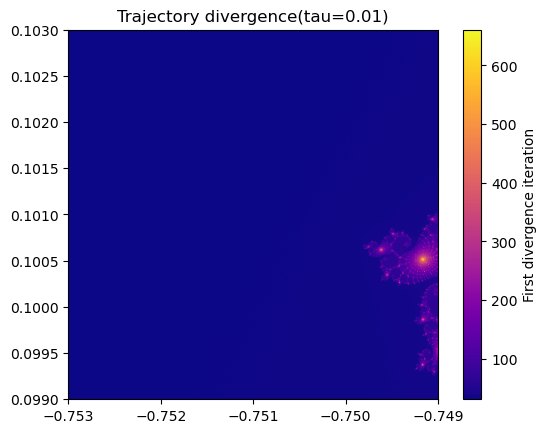

Total pixels: 262144
Number of diverging pixels before max iteration: 262144
Portion Percentage: 100.00%
Correlation: 0.920


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N, MAX_ITER, TAU = 512, 1000, 0.01
x = np.linspace(-0.7530, -0.7490, N)
y = np.linspace( 0.0990, 0.1030, N)

C64 = (x[np.newaxis, :] + 1j * y[:, np.newaxis]).astype(np.complex128)
C32 = C64.astype(np.complex64)
z32 = np.zeros_like(C32)
z64 = np.zeros_like(C64)

diverge = np.full((N, N), MAX_ITER, dtype=np.int32)
active = np.ones((N, N), dtype=bool)

for k in range(MAX_ITER):
    if not active.any(): 
        break
    
    z32[active] = z32[active]**2 + C32[active]
    z64[active] = z64[active]**2 + C64[active]
    diff = (np.abs(z32.real.astype(np.float64) - z64.real)
        + np.abs(z32.imag.astype(np.float64) - z64.imag))
    newly = active & (diff > TAU)
    diverge[newly] = k
    active[newly] = False

plt.imshow(diverge, cmap='plasma', origin='lower',
    extent=[-0.7530, -0.7490, 0.0990, 0.1030])

plt.colorbar(label='First divergence iteration')
plt.title(f'Trajectory divergence(tau={TAU})')
plt.show()

# Calculations
total_pixels = N*N
diverged_pixels  = np.sum(diverge < MAX_ITER) # find pixels diverging before max iterations
portion_diverged = diverged_pixels / total_pixels
print(f'Total pixels: {N*N}')
print(f'Number of diverging pixels before max iteration: {diverged_pixels}')
print(f'Portion Percentage: {portion_diverged*100.0:.2f}%')

# Compute escape iterations
escape_iter = np.full((N, N), MAX_ITER, dtype=np.int32)
z = np.zeros_like(C64)
active_escape = np.ones((N,N), dtype=bool)

for k in range(MAX_ITER):
    z[active_escape] = z[active_escape]**2 + C64[active_escape]
    escaped = active_escape & (np.abs(z) > 2.0)
    escape_iter[escaped] = k
    active_escape[escaped] = False

EARLY_THRESHOLD = 100 # chosen early dicergence
early_mask = diverge < EARLY_THRESHOLD # find all pixel points diverged before 100

valid = diverge < MAX_ITER
correlation = np.corrcoef(diverge[valid].ravel(), escape_iter[valid].ravel())[0,1]
print(f'Correlation: {correlation:.3f}')

**Observations to make**

* What fraction of pixels diverge before max iter?

*According to the calculation above, all the pixels diverge before 1000 iterations.*

* Where do trajectories diverge early?

*According to the colormap image above, the earliest divergences appear in the darkest purple areas. The later divergences appear in the red and orange areas of the Mandelbrot plot. In the actual Mandelbrot set, the earliest divergences seem to appear around the edges of the figure.*

* Does early divergence correlate with high escape iteration counts?

*Yes, early divergence correlates with high escape iteration counts. Early trajectory divergence mostly happens near the edges of the Mandelbrot set, which also corresponds to regions with high escape iteration counts*

##### Milestone 2: Mandelbrot Sensitivity Map

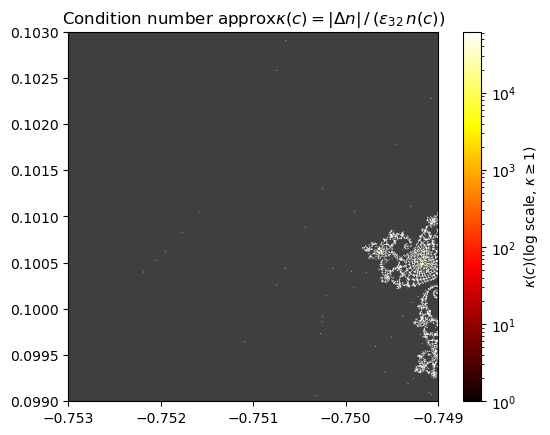

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

N, MAX_ITER = 512, 1000
x = np.linspace(-0.7530, -0.7490, N)
y = np.linspace( 0.0990, 0.1030, N)
C = (x[np.newaxis, :] + 1j * y[:, np.newaxis]).astype(np.complex128)
eps32 = float(np.finfo(np.float32).eps)
delta = np.maximum(eps32 * np.abs(C), 1e-10)

def escape_count(C, max_iter):
    z = np.zeros_like(C); cnt = np.full(C.shape, max_iter, dtype=np.int32)
    esc = np.zeros(C.shape, dtype=bool)

    for k in range(max_iter):
        z[~esc] = z[~esc]**2 + C[~esc]
        newly = ~esc & (np.abs(z) > 2.0)
        cnt[newly] = k; esc[newly] = True
    return cnt

n_base = escape_count(C, MAX_ITER).astype(float)
n_perturb = escape_count(C + delta, MAX_ITER).astype(float)
dn = np.abs(n_base - n_perturb)
kappa = np.where(n_base > 0, dn / (eps32 * n_base), np.nan)
cmap_k = plt.cm.hot.copy(); cmap_k.set_bad('0.25')
vmax = np.nanpercentile(kappa, 99)

plt.imshow(kappa, cmap=cmap_k, origin='lower',
        extent=[-0.7530, -0.7490, 0.0990, 0.1030],
        norm=LogNorm(vmin=1, vmax=vmax))

plt.colorbar(label=r'$\kappa(c)$(log scale, $\kappa\geq1$)' )
plt.title(r'Condition number approx$\kappa(c)= |\Delta n|\,/\,(\varepsilon_{32}\,n(c))$')
plt.show()

Observations:

* Where is κ largest? Does it match the boundary in M1?

* What is κ for interior pixels (n = max iter)?

---